# Decision Tree Classifier: NYC Ride Demand
Same structure as `throo_Project_classification.ipynb`, using a **Decision Tree** model.

In [1]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# CELL 2: LOAD & UNDERSTAND DATA
# ============================================

df = pd.read_csv("throo_nyc_demand.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nData Types:")
display(df.dtypes)

print("\nStatistical Summary:")
display(df.describe().T)

Dataset Shape: (15000, 23)

First 5 rows:


,date,pickup_time,pickup_location,drop_location,distance,duration,ride_type,driver_rating,rider_rating,surge,payment_method,demand,fare,driver_id,driver_latitude,driver_longitude,driver_available,driver_status,request_latitude,request_longitude,pickup_wait_time,cancellation_flag,available_driver_count
0,2025-03-16,05:30:14,Downtown,Suburbs,31.66,98.0,Standard,4.7,4.7,1.0,Cash,Medium,71.99,D3982,40.79546,-74.04151,0,Busy,40.78502,-74.03952,38.5,0,13
1,2025-03-22,14:03:31,Downtown,Downtown,10.87,32.0,Standard,4.7,4.5,1.0,Credit Card,Medium,24.30,D6352,40.76902,-73.94095,0,Busy,40.77979,-73.94965,27.9,0,24
2,2025-03-16,08:16:28,Downtown,Downtown,18.20,55.0,Standard,4.6,4.9,1.0,Credit Card,Medium,41.05,D7170,40.75414,-73.99255,1,Available,40.76850,-74.00629,16.3,1,18
3,2025-03-17,19:37:14,Downtown,Suburbs,21.56,59.0,Standard,4.9,4.6,2.2,Credit Card,High,103.60,D6687,40.77960,-73.98989,1,Available,40.76076,-74.00841,20.4,0,2
4,2025-01-20,14:12:23,Suburbs,Downtown,12.87,30.0,Pool,4.6,4.9,1.0,Digital Wallet,Medium,18.76,D1080,40.93884,-73.86098,1,Available,40.93428,-73.89532,17.9,1,12



Data Types:


date                          str
pickup_time                   str
pickup_location               str
drop_location                 str
distance                  float64
duration                  float64
ride_type                     str
driver_rating             float64
rider_rating              float64
surge                     float64
payment_method                str
demand                        str
fare                      float64
driver_id                     str
driver_latitude           float64
driver_longitude          float64
driver_available            int64
driver_status                 str
request_latitude          float64
request_longitude         float64
pickup_wait_time          float64
cancellation_flag           int64
available_driver_count      int64
dtype: object


Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
distance,14574.0,19.402096,9.547012,1.20000,11.660000,20.08000,27.600000,35.00000
duration,14359.0,58.396058,25.601754,8.00000,38.000000,59.00000,77.000000,125.00000
driver_rating,14239.0,4.500934,0.291312,4.00000,4.200000,4.50000,4.800000,5.00000
rider_rating,15000.0,4.596767,0.234186,4.20000,4.400000,4.60000,4.800000,5.00000
surge,15000.0,1.286033,0.474549,1.00000,1.000000,1.00000,1.600000,2.50000
fare,15000.0,60.901245,45.553277,2.89000,30.000000,50.55000,76.110000,355.07000
driver_latitude,15000.0,40.794913,0.099149,40.58176,40.737248,40.76450,40.885867,41.11097
driver_longitude,15000.0,-73.938236,0.072763,-74.08319,-73.990052,-73.96361,-73.899655,-73.72269
driver_available,15000.0,0.758867,0.427785,0.00000,1.000000,1.00000,1.000000,1.00000
request_latitude,15000.0,40.795003,0.097686,40.60335,40.741127,40.76261,40.889268,41.09027


In [3]:
# ============================================
# CELL 3: DATA CLEANING
# ============================================

print("Missing Values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Convert date
df["date"] = pd.to_datetime(df["date"])

# Combine date and pickup time
df["datetime"] = pd.to_datetime(
    df["date"].astype(str) + " " + df["pickup_time"].astype(str)
)

print("\nDataset after cleaning:", df.shape)

Missing Values:


distance         426
duration         641
driver_rating    761
dtype: int64


Duplicate Rows: 0



Dataset after cleaning: (15000, 24)


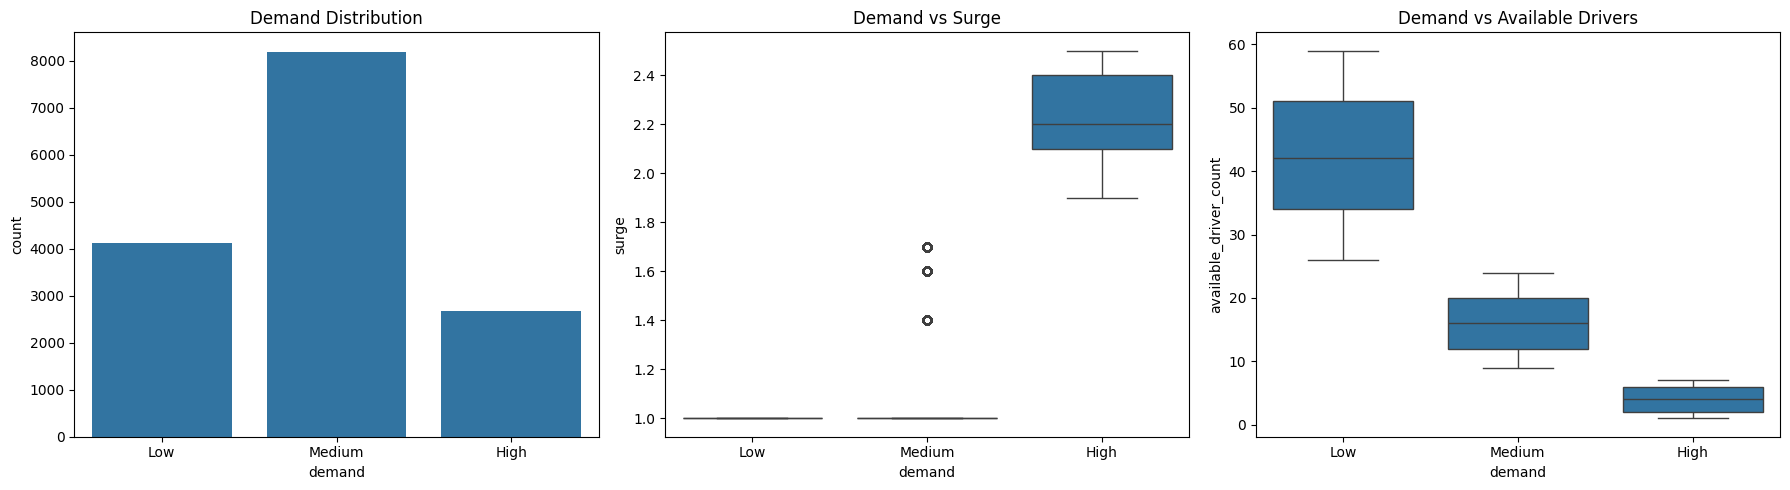

In [4]:
# ============================================
# CELL 4: EXPLORATORY DATA ANALYSIS
# ============================================

order = ["Low", "Medium", "High"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="demand", order=order, ax=axes[0])
axes[0].set_title("Demand Distribution")

sns.boxplot(data=df, x="demand", y="surge", order=order, ax=axes[1])
axes[1].set_title("Demand vs Surge")

sns.boxplot(data=df, x="demand", y="available_driver_count", order=order, ax=axes[2])
axes[2].set_title("Demand vs Available Drivers")

plt.tight_layout()
plt.show()

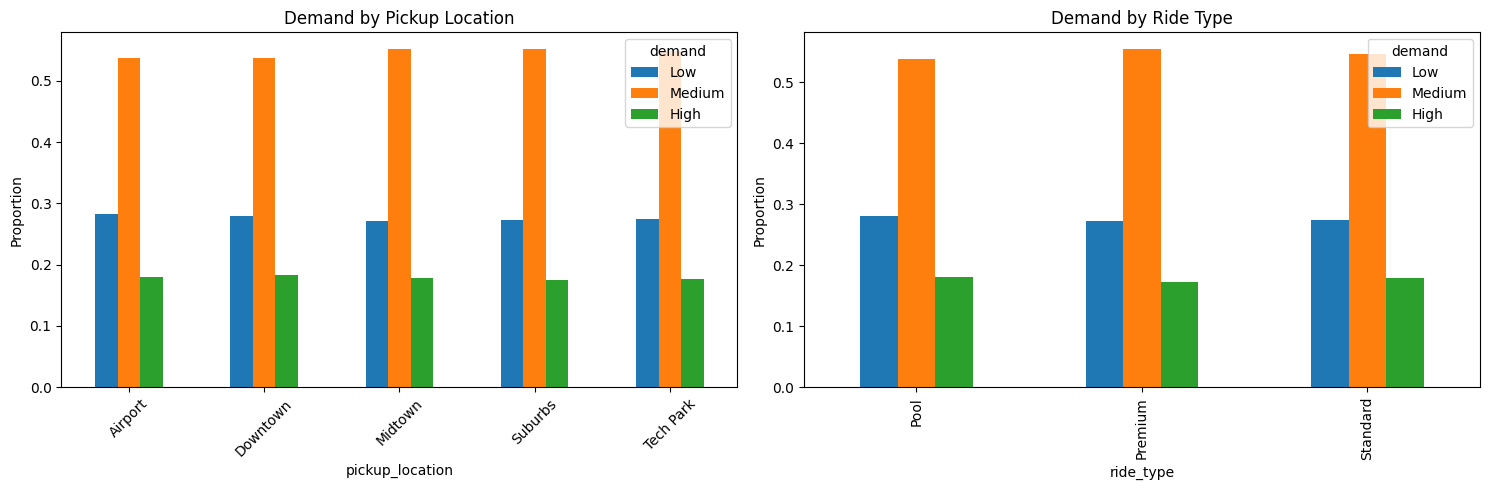

In [5]:
# ============================================
# CELL 5: CATEGORICAL EDA
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pd.crosstab(df["pickup_location"], df["demand"], normalize="index")[order].plot(kind="bar", ax=axes[0])
axes[0].set_title("Demand by Pickup Location")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=45)

pd.crosstab(df["ride_type"], df["demand"], normalize="index")[order].plot(kind="bar", ax=axes[1])
axes[1].set_title("Demand by Ride Type")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

In [6]:
# ============================================
# CELL 6: FEATURE ENGINEERING
# ============================================

df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["week_of_year"] = df["datetime"].dt.isocalendar().week.astype(int)

df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["rush_hour"] = (df["hour"].isin([7, 8, 9, 17, 18, 19, 20])).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

print("Feature engineering completed!")
display(df[["datetime", "hour", "day_of_week", "month", "is_weekend", "rush_hour"]].head())

Feature engineering completed!


,datetime,hour,day_of_week,month,is_weekend,rush_hour
0,2025-03-16 05:30:14,5,6,3,1,0
1,2025-03-22 14:03:31,14,5,3,1,0
2,2025-03-16 08:16:28,8,6,3,1,1
3,2025-03-17 19:37:14,19,0,3,0,1
4,2025-01-20 14:12:23,14,0,1,0,0


In [7]:
# ============================================
# CELL 7: PREPARE FEATURES & TARGET
# ============================================

# ---------------------------------------------------------
# IMPORTANT: surge and available_driver_count decide the demand label
# (see the check below), so they are target leakage.
#   USE_LEAKY_FEATURES = True  -> same as your original notebook
#   USE_LEAKY_FEATURES = False -> honest model without those 2 columns
# ---------------------------------------------------------
USE_LEAKY_FEATURES = True

print("Surge vs Demand:")
display(pd.crosstab(df["surge"], df["demand"]))

columns_to_drop = [
    "demand", "datetime", "date", "pickup_time", "driver_id",
    # Potential data leakage
    "duration", "fare", "rider_rating", "pickup_wait_time", "cancellation_flag"
]

print("\nTarget classes:")
print(df["demand"].value_counts())

Surge vs Demand:


demand,High,Low,Medium
surge,,,
1.0,0,4128,6225
1.4,0,0,746
1.6,0,0,793
1.7,0,0,433
1.9,660,0,0
2.1,446,0,0
2.2,594,0,0
2.4,467,0,0
2.5,508,0,0



Target classes:
demand
Medium    8197
Low       4128
High      2675
Name: count, dtype: int64


In [8]:
# ============================================
# CELL 8: TIME-BASED TRAIN/TEST SPLIT
# ============================================

df = df.sort_values("datetime").reset_index(drop=True)

split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df.drop(columns=columns_to_drop)
y_train = train_df["demand"]

X_test = test_df.drop(columns=columns_to_drop)
y_test = test_df["demand"]

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("\nTraining period:")
print(train_df["datetime"].min(), "to", train_df["datetime"].max())

print("\nTesting period:")
print(test_df["datetime"].min(), "to", test_df["datetime"].max())

Training data: (12000, 25)
Testing data : (3000, 25)

Training period:
2025-01-01 00:00:37 to 2025-03-13 02:28:46

Testing period:
2025-03-13 02:42:18 to 2025-03-30 23:56:17


In [9]:
# ============================================
# CELL 9: PREPROCESSING
# ============================================

categorical_features = [
    "pickup_location", "drop_location", "ride_type", "payment_method", "driver_status"
]

numeric_features = [
    "distance", "driver_rating", "surge", "driver_latitude", "driver_longitude",
    "driver_available", "request_latitude", "request_longitude", "available_driver_count",
    "hour", "day", "day_of_week", "month", "week_of_year", "is_weekend", "rush_hour",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos"
]

if not USE_LEAKY_FEATURES:
    numeric_features = [c for c in numeric_features if c not in ("surge", "available_driver_count")]

# Numerical preprocessing (scaling is not needed for trees, kept for consistency)
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train = X_train[numeric_features + categorical_features]
X_test = X_test[numeric_features + categorical_features]

print("Preprocessing pipeline created!")
print("Features used:", len(numeric_features) + len(categorical_features))

Preprocessing pipeline created!
Features used: 25


In [10]:
# ============================================
# CELL 10: MODEL TRAINING (DECISION TREE)
# ============================================

# 1) Default tree (no depth limit, will overfit)
dt_default = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
])

# 2) Controlled tree (limited depth, less overfitting)
dt_controlled = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ))
])

# 3) Tuned tree (GridSearchCV with time-aware cross validation)
param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_leaf": [1, 10, 30, 60],
    "model__criterion": ["gini", "entropy"]
}

dt_tuned = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
    ]),
    param_grid,
    cv=TimeSeriesSplit(n_splits=4),
    scoring="f1_weighted",
    n_jobs=-1
)

trained_models = {}
predictions = {}

for name, model in {
    "Decision Tree (default)": dt_default,
    "Decision Tree (depth=6)": dt_controlled,
    "Decision Tree (tuned)": dt_tuned
}.items():
    model.fit(X_train, y_train)
    trained_models[name] = model.best_estimator_ if hasattr(model, "best_estimator_") else model
    predictions[name] = model.predict(X_test)
    print(name, "trained successfully!")

print("\nBest tuned parameters:", dt_tuned.best_params_)
print("\nAll models trained!")

Decision Tree (default) trained successfully!


Decision Tree (depth=6) trained successfully!


Decision Tree (tuned) trained successfully!

Best tuned parameters: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 1}

All models trained!


In [11]:
# ============================================
# CELL 11: MODEL EVALUATION & COMPARISON
# ============================================

results = []

for name, pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results)

# Train accuracy shows overfitting (train high, test low = overfit)
results_df["Train Accuracy"] = [
    accuracy_score(y_train, trained_models[m].predict(X_train)) for m in results_df["Model"]
]

display(results_df.sort_values("F1 Score", ascending=False).round(4))

majority = y_test.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {majority:.4f}")

,Model,Accuracy,Precision,Recall,F1 Score,Train Accuracy
0,Decision Tree (default),1.0,1.0,1.0,1.0,1.0
1,Decision Tree (depth=6),1.0,1.0,1.0,1.0,1.0
2,Decision Tree (tuned),1.0,1.0,1.0,1.0,1.0


Majority-class baseline accuracy: 0.5623


FINAL MODEL: Decision Tree (tuned)
Parameters : {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 1}

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       522
         Low       1.00      1.00      1.00       791
      Medium       1.00      1.00      1.00      1687

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



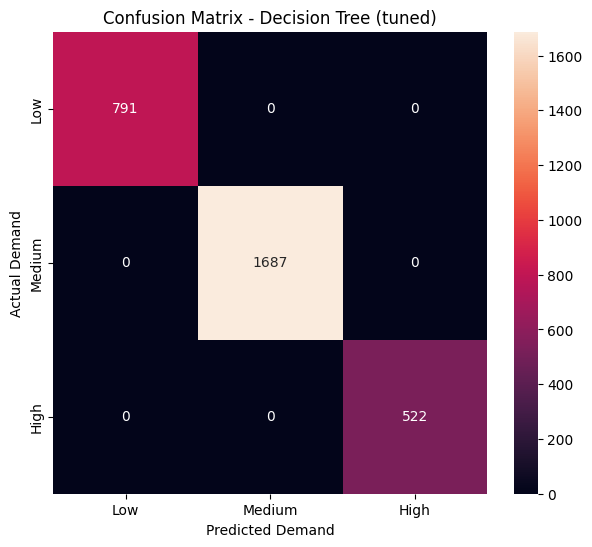

In [12]:
# ============================================
# CELL 12: FINAL MODEL EVALUATION
# ============================================

final_model_name = "Decision Tree (tuned)"

final_model = trained_models[final_model_name]
final_predictions = predictions[final_model_name]

print("FINAL MODEL:", final_model_name)
print("Parameters :", dt_tuned.best_params_)

print("\nClassification Report:")
print(classification_report(y_test, final_predictions, zero_division=0))

cm = confusion_matrix(y_test, final_predictions, labels=["Low", "Medium", "High"])

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.xlabel("Predicted Demand")
plt.ylabel("Actual Demand")
plt.title(f"Confusion Matrix - {final_model_name}")
plt.show()

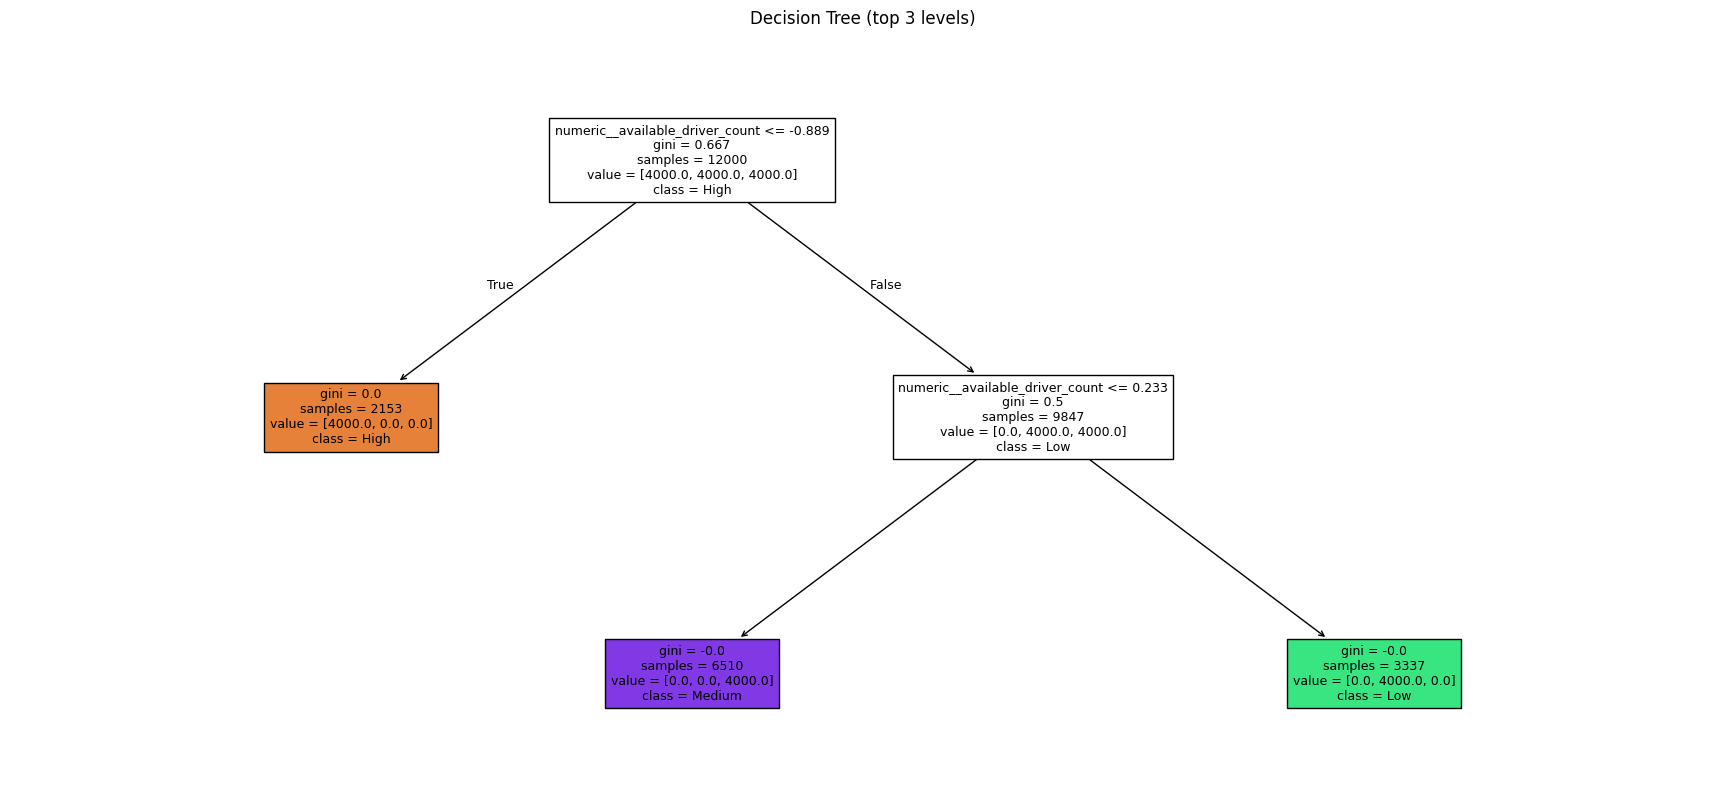

Tree depth : 2
Leaf nodes : 3

Decision rules (first levels):
|--- numeric__available_driver_count <= -0.89
|   |--- class: High
|--- numeric__available_driver_count >  -0.89
|   |--- numeric__available_driver_count <= 0.23
|   |   |--- class: Medium
|   |--- numeric__available_driver_count >  0.23
|   |   |--- class: Low



In [13]:
# ============================================
# CELL 13: VISUALIZE THE TREE
# ============================================

model = final_model.named_steps["model"]
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=model.classes_,
    filled=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree (top 3 levels)")
plt.show()

print("Tree depth :", model.get_depth())
print("Leaf nodes :", model.get_n_leaves())

print("\nDecision rules (first levels):")
print(export_text(model, feature_names=list(feature_names), max_depth=3))

,Feature,Importance
8,numeric__available_driver_count,1.0
1,numeric__driver_rating,0.0
0,numeric__distance,0.0
3,numeric__driver_latitude,0.0
4,numeric__driver_longitude,0.0
5,numeric__driver_available,0.0
2,numeric__surge,0.0
6,numeric__request_latitude,0.0
7,numeric__request_longitude,0.0
9,numeric__hour,0.0


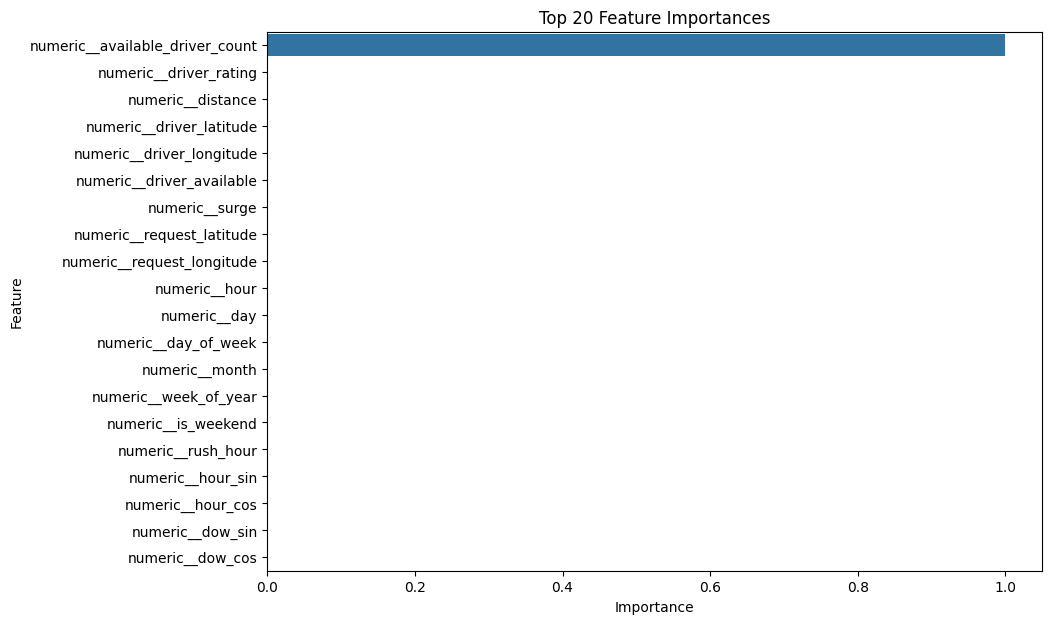

In [14]:
# ============================================
# CELL 14: FEATURE IMPORTANCE
# ============================================

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

display(importance_df)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Top 20 Feature Importances")
plt.show()

In [15]:
# ============================================
# CELL 15: SAVE MODEL
# ============================================

joblib.dump(final_model, "nyc_demand_decision_tree_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [16]:
# ============================================
# SEE FINAL MODEL PREDICTION
# ============================================

sample = X_test.iloc[[0]]

actual = y_test.iloc[0]
predicted = final_model.predict(sample)[0]

print("Actual Demand    :", actual)
print("Predicted Demand :", predicted)

Actual Demand    : Low
Predicted Demand : Low


In [17]:
# ============================================
# PREDICTION PROBABILITIES
# ============================================

probabilities = final_model.predict_proba(sample)

probability_df = pd.DataFrame(probabilities, columns=final_model.classes_)

display(probability_df)

,High,Low,Medium
0,0.0,1.0,0.0
